In [1]:
# import libraries
import requests
import ast
import re
import pandas as pd
import nltk
import os
import zipfile
import numpy as np
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize
import os
from sklearn.feature_extraction import text
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import seaborn as sns
from collections import Counter
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
# To download folder
from google.colab import files
import shutil

from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster.hierarchy import ward, dendrogram
import os
import re
import zipfile
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans
import matplotlib.cm as cm
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
# load in raw data( to vectorize)
data = pd.read_csv('Raw Master Data.csv')
data.head()

,LABEL,Content
0,universal healthcare,universal basic income offers strings attached...
1,universal healthcare,universal basic income politically controversi...
2,universal healthcare,senators grilled robert kennedy trump pick hea...
3,universal healthcare,health secretary says reform poverty ambition ...
4,universal healthcare,initiative follows pressure from several artis...


In [3]:
# Instantiate Vectorizer, max features 1000
MyCountV=CountVectorizer(
        input="content",  ## because we have a csv file
        lowercase=True,
        stop_words = "english",
        max_features = 1000)

In [4]:
# fit the vectorizer to the data
Vect1 = MyCountV.fit_transform(data['Content'])

CountVDF = pd.DataFrame(Vect1.toarray(), columns=MyCountV.get_feature_names_out())

# Check results
print(CountVDF)

      10  100  1000  100000  11  12  14  15  18  20  ...  yeah  year  years  \
0      0    0     0       0   0   0   0   0   0   0  ...     0     0      0   
1      0    0     0       0   0   0   0   0   0   0  ...     0     0      0   
2      0    0     0       0   0   0   0   0   0   0  ...     0     0      0   
3      0    0     0       0   0   0   0   0   0   0  ...     0     0      0   
4      0    0     0       0   0   0   0   0   0   0  ...     0     0      0   
...   ..  ...   ...     ...  ..  ..  ..  ..  ..  ..  ...   ...   ...    ...   
2104   0    0     0       0   0   0   0   0   0   0  ...     0     0      0   
2105   0    0     0       0   0   0   0   0   0   0  ...     0     0      0   
2106   0    0     0       0   0   0   0   0   0   0  ...     0     0      0   
2107   0    0     0       0   0   0   0   0   0   0  ...     0     0      0   
2108   0    0     0       0   0   0   0   0   0   0  ...     0     0      0   

      yes  york  youd  youll  young  youre  youve  

In [5]:
# clean data
for nextcol in CountVDF.columns:

    if(bool(re.search(r'[^a-zA-Z]', nextcol))):
       CountVDF=CountVDF.drop([nextcol], axis=1)

for nextcol in CountVDF.columns:
    if(len(str(nextcol))<=4): # remove words less than 4
         CountVDF=CountVDF.drop([nextcol], axis=1)


print(CountVDF)

      ability  absolutely  accept  accepting  access  accident  according  \
0           0           0       0          0       0         0          0   
1           0           0       0          0       0         0          0   
2           0           0       0          0       0         0          0   
3           0           0       0          0       0         0          0   
4           0           0       0          0       0         0          0   
...       ...         ...     ...        ...     ...       ...        ...   
2104        0           0       0          0       0         0          0   
2105        0           0       0          0       0         0          0   
2106        0           0       0          0       0         0          0   
2107        0           0       0          0       0         0          0   
2108        0           0       0          0       0         0          0   

      account  accounts  action  ...  worth  wouldnt  wouldve  wound  wrong

In [6]:
dist = euclidean_distances(Vect1)
print(np.round(dist,0))

[[ 0.  3.  4. ...  6.  4. 41.]
 [ 3.  0.  3. ...  5.  4. 41.]
 [ 4.  3.  0. ...  5.  4. 41.]
 ...
 [ 6.  5.  5. ...  0.  6. 42.]
 [ 4.  4.  4. ...  6.  0. 41.]
 [41. 41. 41. ... 42. 41.  0.]]


In [7]:
cosdist = 1 - cosine_similarity(Vect1)
print(np.round(cosdist,2))

[[ 0.    0.58  1.   ...  1.    0.89  0.84]
 [ 0.58  0.    1.   ...  1.    1.    0.82]
 [ 1.    1.   -0.   ...  1.    1.    0.7 ]
 ...
 [ 1.    1.    1.   ...  0.    1.    0.95]
 [ 0.89  1.    1.   ...  1.   -0.    0.95]
 [ 0.84  0.82  0.7  ...  0.95  0.95  0.  ]]


In [8]:
# Append on LABEL column for later graphing
CountVDF['LABEL'] = data['LABEL']
print(CountVDF)

      ability  absolutely  accept  accepting  access  accident  according  \
0           0           0       0          0       0         0          0   
1           0           0       0          0       0         0          0   
2           0           0       0          0       0         0          0   
3           0           0       0          0       0         0          0   
4           0           0       0          0       0         0          0   
...       ...         ...     ...        ...     ...       ...        ...   
2104        0           0       0          0       0         0          0   
2105        0           0       0          0       0         0          0   
2106        0           0       0          0       0         0          0   
2107        0           0       0          0       0         0          0   
2108        0           0       0          0       0         0          0   

      account  accounts  action  ...  wouldnt  wouldve  wound  wrong  years

In [9]:
# Create an X and y set for Kmeans
X = CountVDF.copy()
X = X.drop(columns = ['LABEL'])
y = CountVDF['LABEL']

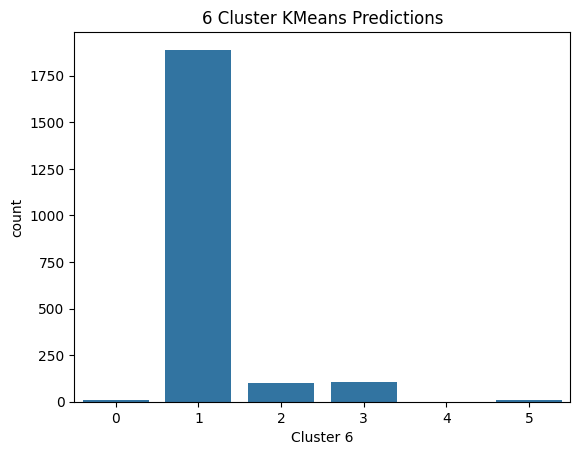

In [10]:
# Instantiate for 6 clusters
model = KMeans(n_clusters=6)

predictions = model.fit_predict(X)

# Add cluster predictions to dataframe for graphing
CountVDF['Cluster 6'] = predictions

# Create a graph of the clusters
sns.countplot(x = CountVDF['Cluster 6'])
plt.title('6 Cluster KMeans Predictions')
plt.show()

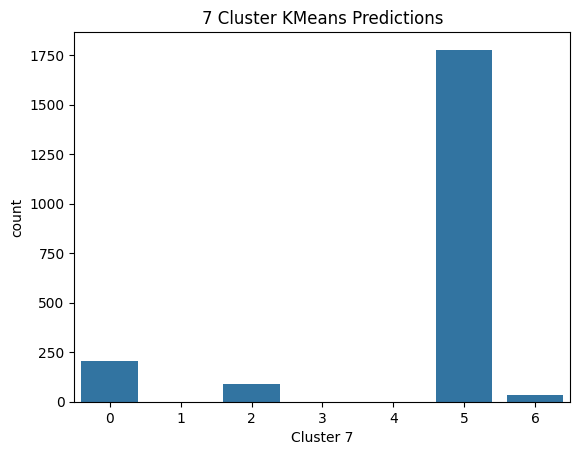

In [11]:
# Instantiate for 7 clusters next

model2 = KMeans(n_clusters=7)

predictions2 = model2.fit_predict(X)

# Add cluster predictions to dataframe for graphing
CountVDF['Cluster 7'] = predictions2

# Create a graph of the clusters
sns.countplot(x = CountVDF['Cluster 7'])
plt.title('7 Cluster KMeans Predictions')
plt.show()

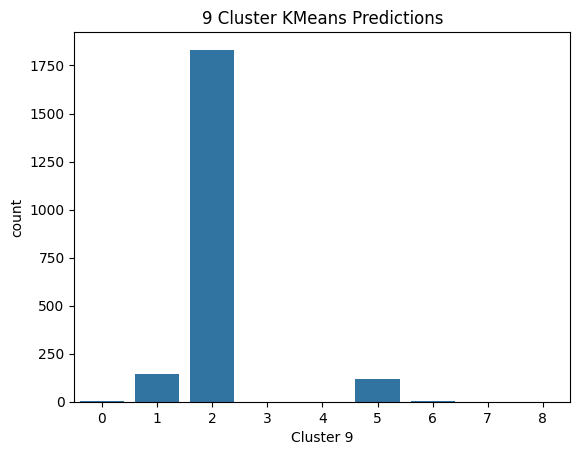

In [12]:
# Instantiate for 9 clusters last, given 9 total labels for data

model3 = KMeans(n_clusters=9)

predictions3 = model3.fit_predict(X)

# Add cluster predictions to dataframe for graphing
CountVDF['Cluster 9'] = predictions3

# Create a graph of the clusters
sns.countplot(x = CountVDF['Cluster 9'])
plt.title('9 Cluster KMeans Predictions')
plt.show()

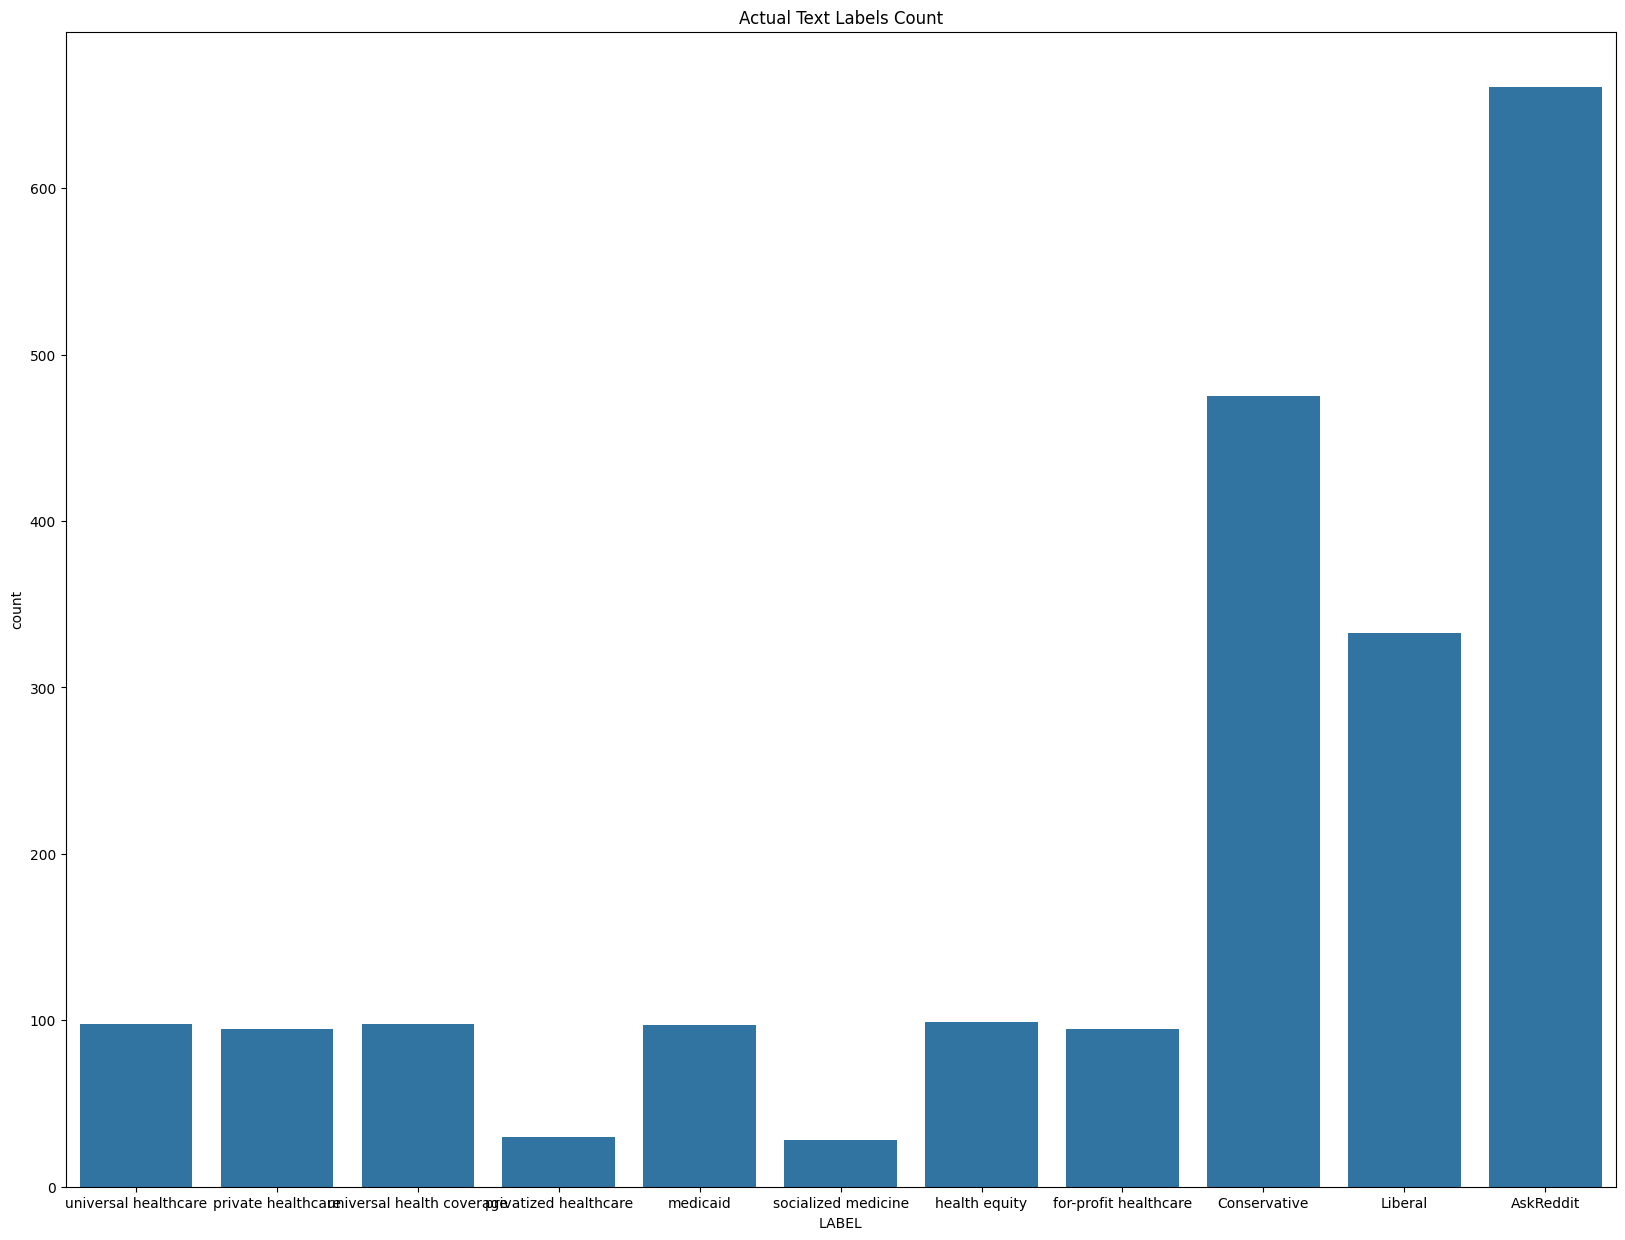

In [13]:
# Graph a count of the actual labels to compare accuracy?
plt.figure(figsize = (20,15))
sns.countplot(x = CountVDF['LABEL'])
plt.title('Actual Text Labels Count')
plt.show()

In [14]:
X.head()

,ability,absolutely,accept,accepting,access,accident,according,account,accounts,action,...,worth,wouldnt,wouldve,wound,wrong,years,youll,young,youre,youve
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
# Silhouette score graphs
iterations = [3, 4, 6, 7, 9]
silhouette_scores = []

For n_clusters = 3, the average silhouette_score is: 0.5025
For n_clusters = 4, the average silhouette_score is: 0.5109
For n_clusters = 6, the average silhouette_score is: 0.3622
For n_clusters = 7, the average silhouette_score is: 0.3611
For n_clusters = 9, the average silhouette_score is: 0.3063


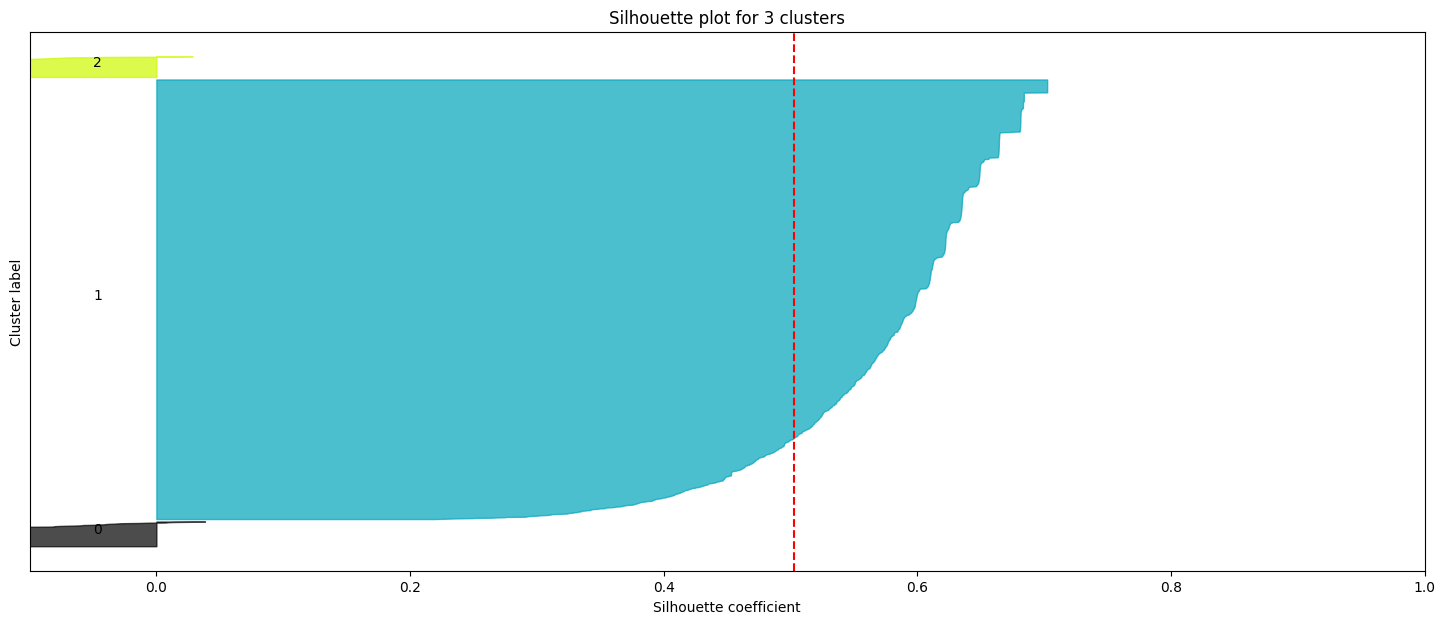

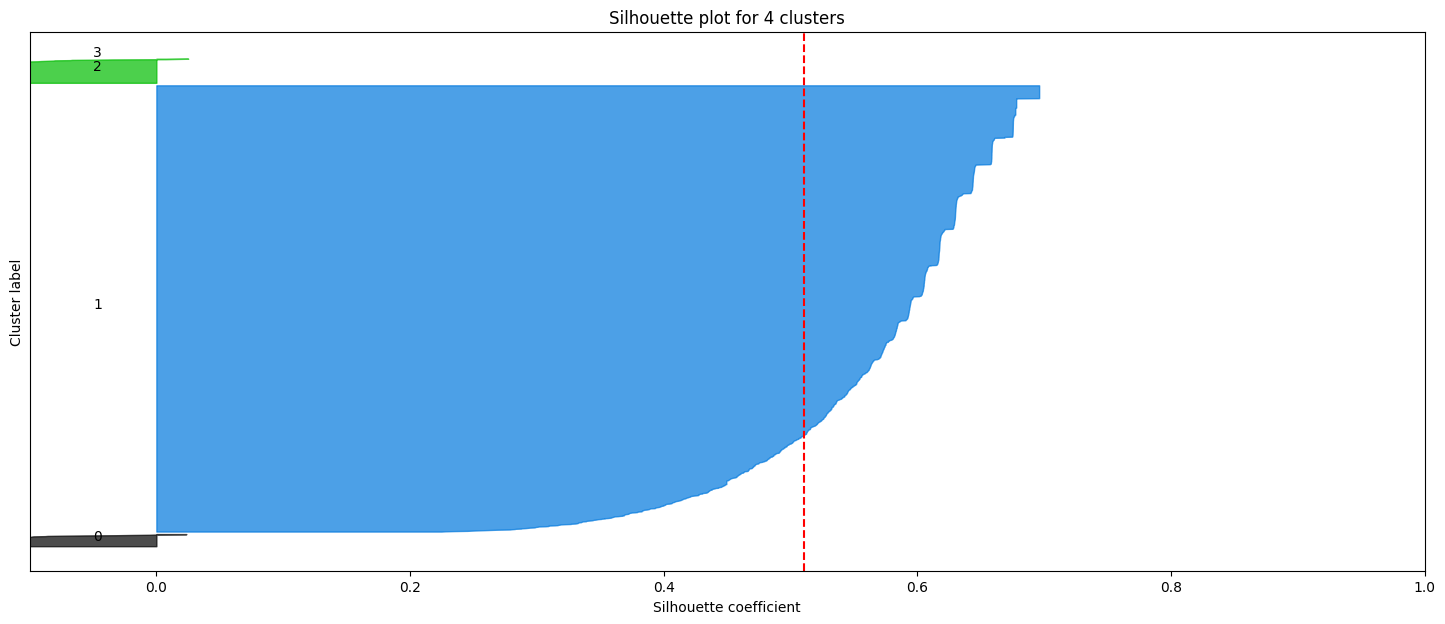

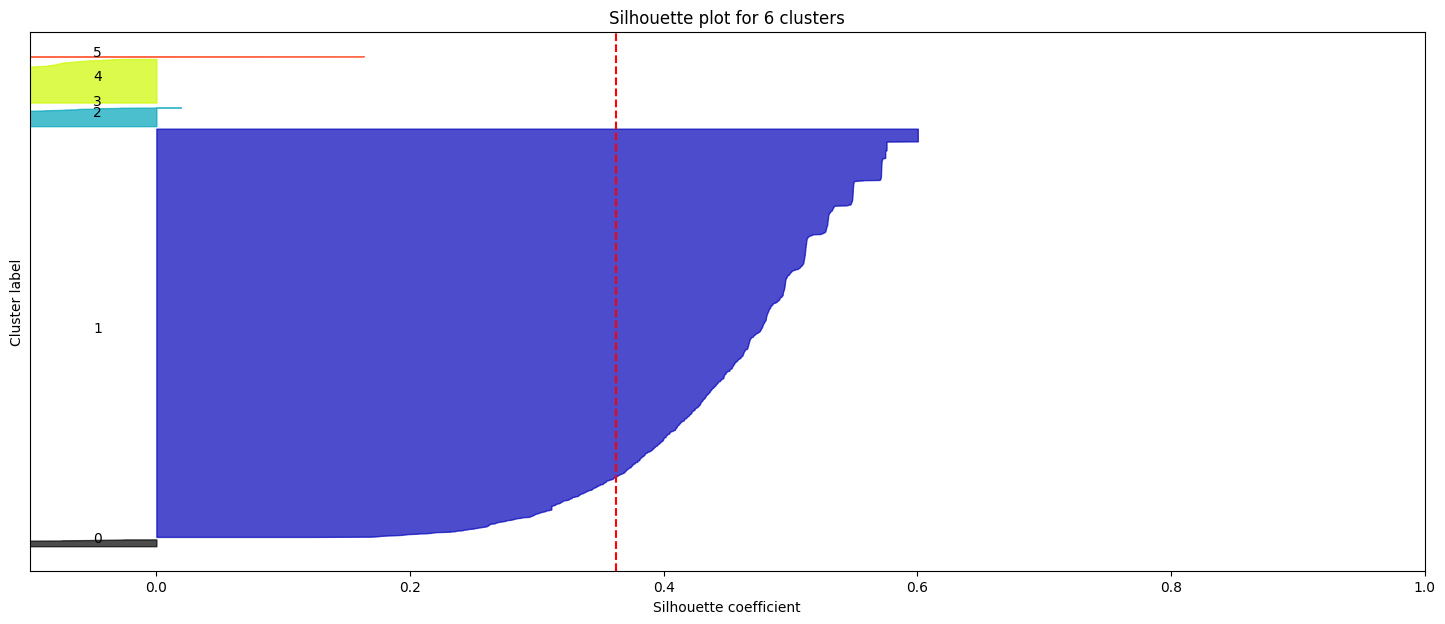

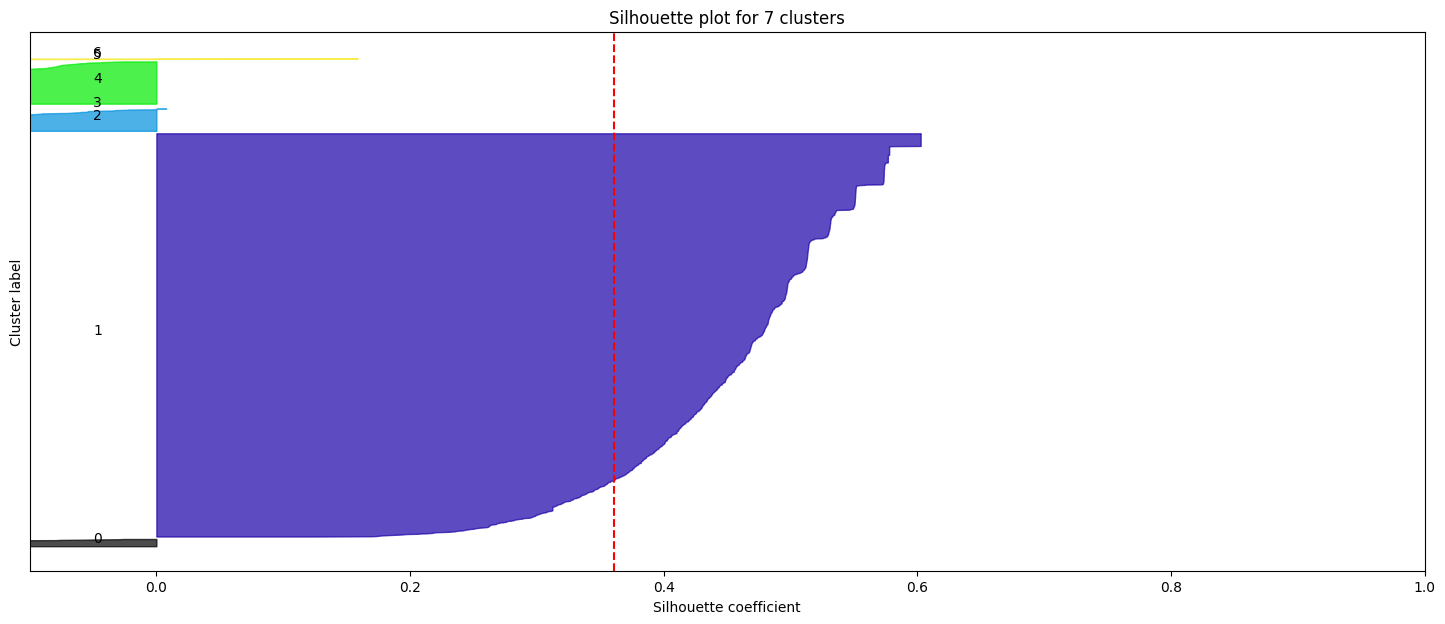

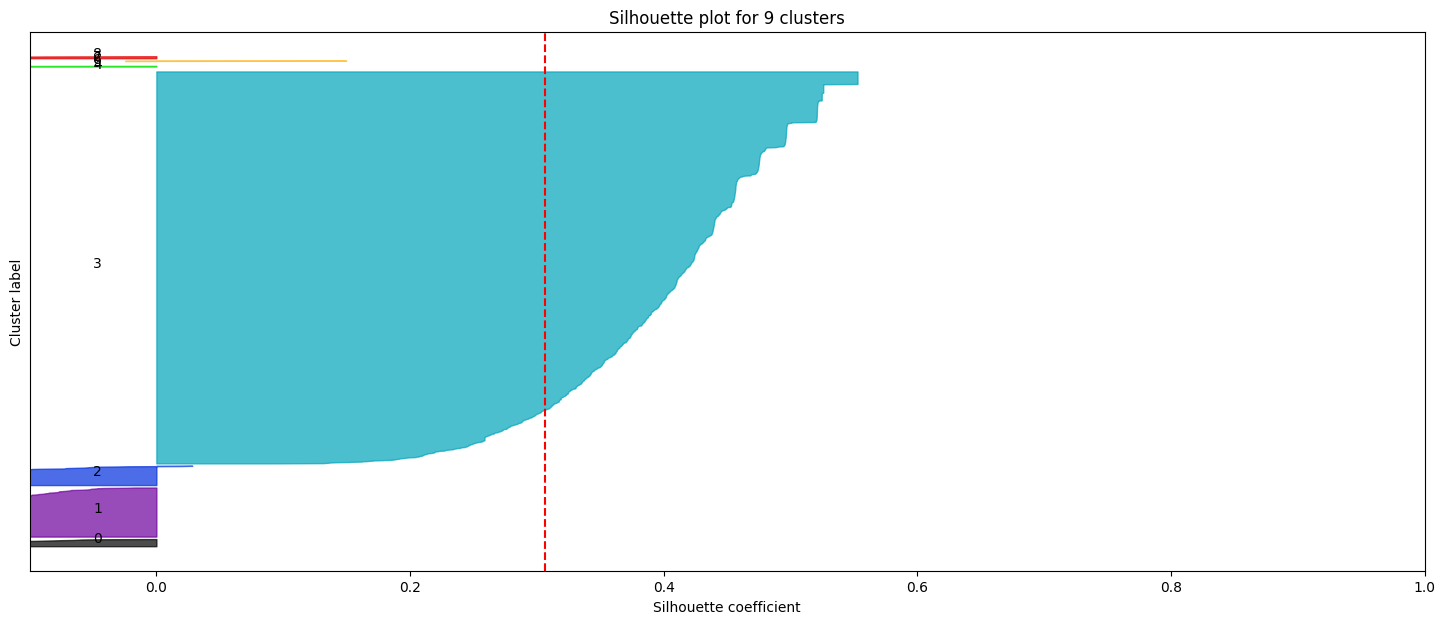

In [16]:
# Silhouette plot implementation

for n_clusters in iterations:
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)

    # Fit KMeans with current n_clusters value
    kmeans = KMeans(n_clusters=n_clusters, random_state=801) # random state for reproduceability
    cluster_labels = kmeans.fit_predict(X)

    # Calculate silhouette score, print it with each plot for comparison
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is: {silhouette_avg:.4f}")

    # Compute silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    # Plot the silhouette scores for each sample
    y_lower = 10
    for i in range(n_clusters):
        # Aggregate silhouette scores for cluster i
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute new y_lower for next plot
        y_lower = y_upper + 10  # 10 for space between clusters

    # Add vertical line for average silhouette score, the higher the better
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    # Next, add axis labels

    ax1.set_title(f"Silhouette plot for {n_clusters} clusters")
    ax1.set_xlabel("Silhouette coefficient")
    ax1.set_ylabel("Cluster label")

    # Clear y-axis labels and set limits
    ax1.set_yticks([])
    ax1.set_xlim([-0.1, 1])

plt.show()

In [17]:
# Next, do a random sample of the data to do a dendrogram
# Do it by rerunning CountVectorizer for a 50-feature max, then dendrogram that
### Vectorize
## Instantiate your CV
MyCountV2=CountVectorizer(
        input="content",  ## because we have a csv file
        lowercase=True,
        stop_words = "english",
        max_features=50
        )

In [18]:
## Use your CV
MyDTM2 = MyCountV2.fit_transform(data['Content'])  # create a sparse matrix
print(type(MyDTM2))


ColumnNames2=MyCountV2.get_feature_names_out()
#print(type(ColumnNames))

<class 'scipy.sparse._csr.csr_matrix'>


In [19]:
MyDTM_DF2=pd.DataFrame(MyDTM2.toarray(),columns=ColumnNames2)
MyDTM_DF2.head()

,better,care,cost,costs,countries,country,doctor,doctors,doesnt,dont,...,trump,universal,want,way,work,world,year,years,yes,youre
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


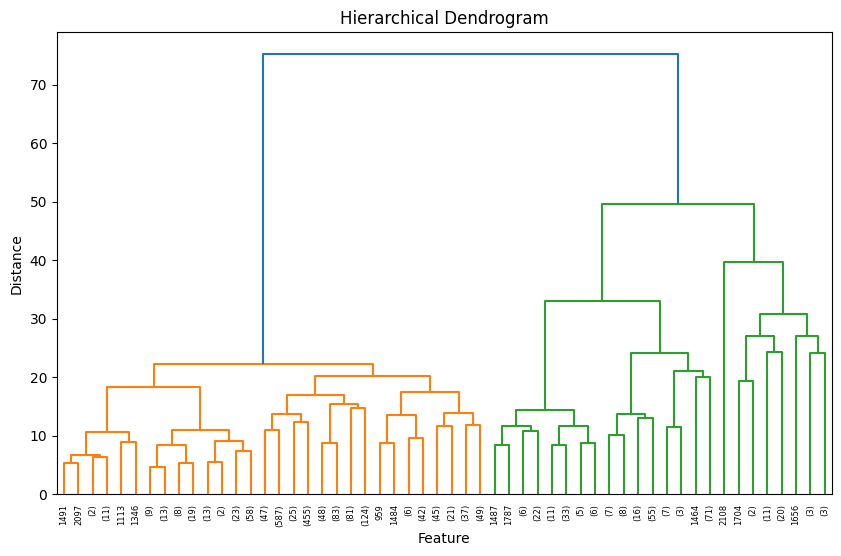

In [20]:
# Dendrogram creation, first create linkage matrix
linkage_matrix = sch.linkage(MyDTM_DF2, method='ward')

# Create dendrogram plot
plt.figure(figsize = (10,6))
sch.dendrogram(linkage_matrix, truncate_mode="level", p=5)
plt.title('Hierarchical Dendrogram')
plt.ylabel('Distance')
plt.xlabel('Feature')
plt.show()

In [21]:
# Next, PCA the data and reduce dimensionality to 3, then graph and compare
# First, standard scale the data
scaler = StandardScaler() ##Instantiate
DF=scaler.fit_transform(X) ## Scale data
print(DF)
print(type(DF))
print(DF.shape)

[[-0.07129796 -0.13933283 -0.07328626 ... -0.08523258 -0.20017253
  -0.07328626]
 [-0.07129796 -0.13933283 -0.07328626 ... -0.08523258 -0.20017253
  -0.07328626]
 [-0.07129796 -0.13933283 -0.07328626 ... -0.08523258 -0.20017253
  -0.07328626]
 ...
 [-0.07129796 -0.13933283 -0.07328626 ... -0.08523258 -0.20017253
  -0.07328626]
 [-0.07129796 -0.13933283 -0.07328626 ... -0.08523258 -0.20017253
  -0.07328626]
 [-0.07129796 -0.13933283 -0.07328626 ... -0.08523258 -0.20017253
  -0.07328626]]
<class 'numpy.ndarray'>
(2109, 760)


In [22]:
## Instantiate PCA and choose how many components
MyPCA=PCA(n_components=3)
# Project the original data into the PCA space
Result=MyPCA.fit_transform(DF)

In [23]:
## Print the values of the first component
#print(Result[:,0])
print(Result) ## Print the new (transformed) dataset
print("The eigenvalues:", MyPCA.explained_variance_)

[[-6.86628820e-01  6.05228452e-01 -1.13161057e+00]
 [-1.61083978e+00  1.75803486e-01 -7.44539428e-01]
 [-2.05907130e+00  1.15424233e+00 -1.52922938e+00]
 ...
 [ 1.33643220e+00 -2.95522238e-02 -4.99178451e-01]
 [-8.86677450e-01 -5.05490929e-01 -2.11509335e-01]
 [ 1.05511363e+02  9.38320024e+01 -6.76442512e+01]]
The eigenvalues: [25.24139437 15.55231441 14.6810636 ]


In [24]:
MyCov=np.cov(Result.T)
print("Covar of the PC PCA Matrix: \n", MyCov) ## The variance here (on the diagonal) will match the eigenvalues
print("The relative eigenvalues are:",MyPCA.explained_variance_ratio_)
print("The actual eigenvalues are:", MyPCA.explained_variance_)
EVects=MyPCA.components_
print("The eigenvectors are:\n",EVects)

Covar of the PC PCA Matrix: 
 [[2.52413944e+01 0.00000000e+00 1.72579640e-15]
 [0.00000000e+00 1.55523144e+01 1.29434730e-15]
 [1.72579640e-15 1.29434730e-15 1.46810636e+01]]
The relative eigenvalues are: [0.03319661 0.02045387 0.01930803]
The actual eigenvalues are: [25.24139437 15.55231441 14.6810636 ]
The eigenvectors are:
 [[ 0.04015432  0.02141292  0.02285627 ...  0.02162594  0.06643471
   0.01177852]
 [-0.0091107  -0.00727858 -0.00606297 ... -0.01211299 -0.02055387
  -0.00380699]
 [ 0.00321045  0.00294814  0.00667897 ...  0.00963228  0.0105722
   0.00027524]]


[ 6.05228452e-01  1.75803486e-01  1.15424233e+00 ... -2.95522238e-02
 -5.05490929e-01  9.38320024e+01]


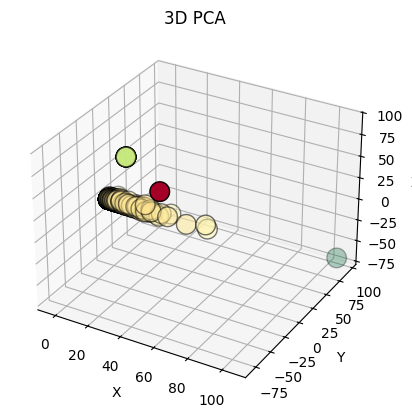

In [25]:
fig2 = plt.figure()
    #figsize=(12, 12))
ax2 = fig2.add_subplot(projection='3d')
#Axes3D(fig2, rect=[0, 0, .90, 1], elev=48, azim=134)

x=Result[:,0]
y=Result[:,1]
z=Result[:,2]
print(y)

ax2.scatter(x,y,z, cmap="RdYlGn", edgecolor='k', s=200, c=y)
#surf2 = ax2.plot_surface(x, y, z, cmap='viridis')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('3D PCA')
#
plt.show()

[25.24139437 40.79370878 55.47477238]
[0.03319661 0.02045387 0.01930803]


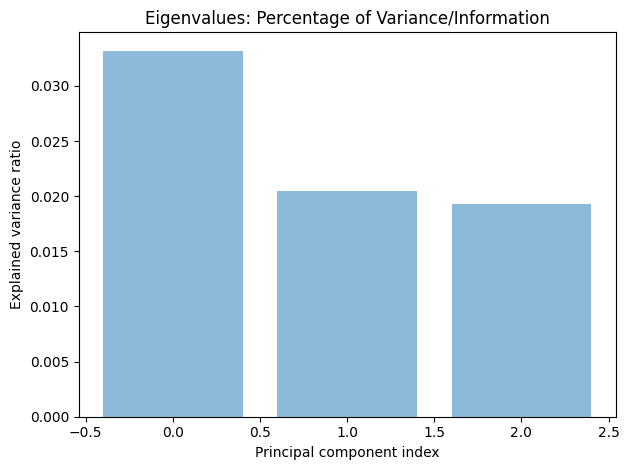

In [26]:
fig3=plt.figure()
ACCUM_eigenvalues = np.cumsum(MyPCA.explained_variance_)
print(ACCUM_eigenvalues)
print(MyPCA.explained_variance_ratio_)
plt.bar(range(0,len(MyPCA.explained_variance_ratio_)), MyPCA.explained_variance_ratio_,
        alpha=0.5, align='center', label='Individual Explained Variances')
#plt.step(range(0,len(ACCUM_eigenvalues)), ACCUM_eigenvalues, where='mid',label='Cumulative Explained Variances')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title("Eigenvalues: Percentage of Variance/Information")
#plt.legend(loc='best')
plt.tight_layout()
plt.show()

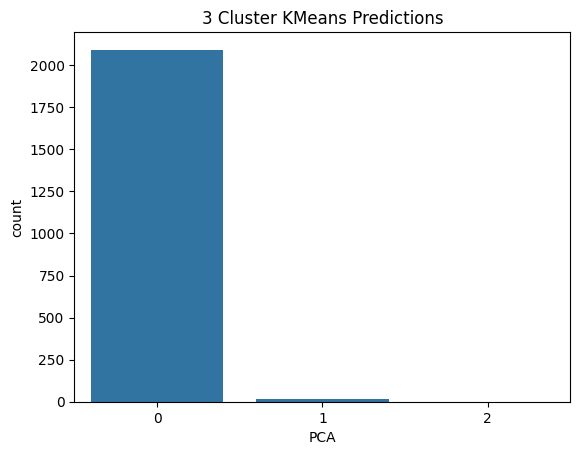

In [28]:
# Kmeans PCA
# Instantiate for 3 clusters

model4 = KMeans(n_clusters=3)

predictions4 = model4.fit_predict(Result)

# Add cluster predictions to dataframe for graphing
CountVDF['PCA'] = predictions4

# Create a graph of the clusters
sns.countplot(x = CountVDF['PCA'])
plt.title('3 Cluster KMeans Predictions')
plt.show()